In [ ]:
import h5py
from movement.io import load_poses
from pathlib import Path

import h5py
import numpy as np
import xarray as xr
from movement.io import load_poses
from movement.kinematics import compute_acceleration, compute_speed, compute_velocity
from movement.utils.vector import cart2pol, compute_norm, convert_to_unit


data_folder = Path(r"C:\Users\aksel\Desktop\präsi\birdpark_tracking")
h5_path = data_folder / "BP_2020-10-17_06-00-01_809497_0000000_pose3d.h5"

# bird 1: male (yellow)
# bird 2: female (purple)


KEYPOINT_NAMES = ["beak tip", "head center", "backpack center", "tail base", "tail tip"]
FPS = 47.6837158203125


def load_birdpark_pose3d(path: str | Path, fps: float = FPS) -> xr.Dataset:
    with h5py.File(path, "r") as file:
        keypoints = file["inference/keypoints_3d"][:]
        confidence = file["inference/kp_confidence_top"][:]
    return load_poses.from_numpy(
        position_array=keypoints.transpose(1, 3, 2, 0),
        confidence_array=confidence.transpose(1, 2, 0),
        keypoint_names=KEYPOINT_NAMES,
        fps=fps,
        source_software="BirdPark",
    )


def partner_view(data: xr.DataArray) -> xr.DataArray:
    individuals = data.individual.values
    return data.sel(individual=individuals[::-1]).assign_coords(individual=individuals)


def angle_between(u: xr.DataArray, v: xr.DataArray) -> xr.DataArray:
    cosine = (convert_to_unit(u) * convert_to_unit(v)).sum("space").clip(-1, 1)
    return np.degrees(np.arccos(cosine))


def tail_centroid(position: xr.DataArray) -> xr.DataArray:
    return position.sel(keypoint=["tail base", "tail tip"]).mean(dim="keypoint")


def add_kinematics(ds: xr.Dataset) -> xr.Dataset:
    return ds.assign(
        velocity=compute_velocity(ds.position),
        acceleration=compute_acceleration(ds.position),
        speed=compute_speed(ds.position),
    )


def add_social_features(ds: xr.Dataset) -> xr.Dataset:
    position = ds.position
    backpack = position.sel(keypoint="backpack center")
    body_origin = tail_centroid(position)
    body_vector = position.sel(keypoint="beak tip") - body_origin
    partner_head = partner_view(position.sel(keypoint="head center"))

    return ds.assign(
        backpack_distance=compute_norm(backpack - partner_view(backpack)),
        beak_to_backpack=compute_norm(position.sel(keypoint="beak tip") - backpack),
        body_azimuth=cart2pol(body_vector.sel(space=["x", "y"])).sel(space_pol="phi"),
        body_to_partner_angle=angle_between(body_vector, partner_head - body_origin),
    )


ds = add_social_features(add_kinematics(load_birdpark_pose3d(h5_path)))

In [ ]:

import pandas as pd
from ethograph.io.pairing import pair_media
from ethograph.io.netcdf import netcdf_engine



pose_path = data_folder / "BP_2020-10-17_06-00-01_809497_0000000_pose3d.nc"
ds = ds.load()          # or ds.compute() — pull everything into memory
ds.close()              # drop the netCDF4 handle
xr.backends.file_manager.FILE_CACHE.clear()   # nuke the LRU cache if needed
ds.to_netcdf(pose_path, engine=netcdf_engine(pose_path))

(video_path,) = data_folder.glob("*.mp4")

session_table = pd.DataFrame(
    {
        "trial": [1],
        "video_cam-1": [str(video_path)],
        "pose_3d": [str(pose_path)],
    }
)

pair_media(
    trial_table=session_table,
    stream_rates={"video": FPS, "pose": FPS},
    output_path=data_folder / ".ethograph" / "alignment.nwb",
    pose_fps=FPS,
)

root pynwb.file.NWBFile at 0x1589413010208
Fields:
  acquisition: {
    pose_3d <class 'pynwb.image.ImageSeries'>,
    video_cam-1 <class 'pynwb.image.ImageSeries'>
  }
  devices: {
    3d <class 'pynwb.device.Device'>,
    cam-1 <class 'pynwb.device.Device'>
  }
  file_create_date: [datetime.datetime(2026, 9, 22, 15, 57, 3, 629162, tzinfo=tzlocal())]
  identifier: d76d82a3-0665-46b4-a68c-a0f6cf2f0d85
  session_description: NWB file for media alignment (ethograph generated).
  session_start_time: 2026-09-22 15:57:03.628651+02:00
  timestamps_reference_time: 2026-09-22 15:57:03.628651+02:00
  trials: trials <class 'pynwb.epoch.TimeIntervals'>

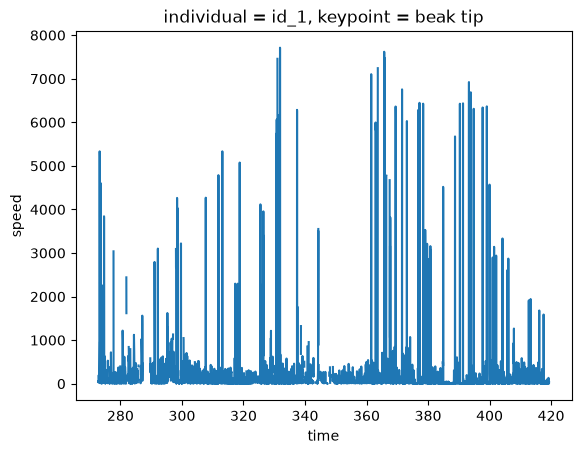

In [32]:
ds.speed.isel(keypoint=0, individual=1).plot()

In [15]:
ds.to_netcdf(r"file.nc")

In [ ]:
from pathlib import Path

import numpy as np
from movement.io import load_poses

BOX_COLUMNS = 5

path =r"C:\Users\aksel\Desktop\präsi\birdpark_tracking\BP_2020-10-17_06-00-01_809497_0000000_pose3d.h5"



def load_yolo_pose_txt(
    label_dir: str | Path,
    n_keypoints: int,
    max_individuals: int,
    frame_size: tuple[int, int],
    fps: float,
):
    label_files = sorted(Path(label_dir).glob("*.txt"))
    positions = np.full((len(label_files), 2, n_keypoints, max_individuals), np.nan)
    confidences = np.full((len(label_files), n_keypoints, max_individuals), np.nan)
    keypoint_end = BOX_COLUMNS + 3 * n_keypoints

    for frame, label_file in enumerate(label_files):
        rows = np.loadtxt(label_file, ndmin=2)
        if rows.size == 0:
            continue
        has_track_ids = rows.shape[1] > keypoint_end
        ids = rows[:, -1].astype(int) if has_track_ids else np.arange(len(rows))
        keypoints = rows[:, BOX_COLUMNS:keypoint_end].reshape(-1, n_keypoints, 3)
        positions[frame, :, :, ids] = (keypoints[..., :2] * frame_size).transpose(0, 2, 1)
        confidences[frame, :, ids] = keypoints[..., 2]

    return load_poses.from_numpy(
        position_array=positions,
        confidence_array=confidences,
        fps=fps,
        source_software="YOLO-Pose",
    )




ModuleNotFoundError: No module named 'ultralytics'